# Small Jet Tagger with HGQ 1

### This notebook contains a minimal example to train a jet tagger that can be deployed on FPGAs with the High Granularlity Quantization (HGQ) framework.

### Task: classify a jet into 5 classes from 16 scalar features. Assume a level-trigger like environment where latency and resource constraints are tight ($<100$ ns and $\mathcal{O}(10000)$ LUTs).

#### Before starting, the user is encouraged to skim through the documentation at https://calad0i.github.io/HGQ/. For more details, please refer to our paper at https://arxiv.org/abs/2405.00645.

#### This notebook is for demostration of the framework. For the best model performance (accuracy-resource tradeoff), please refer to https://github.com/calad0i/HGQ-demos for code and configurations for production runs.

In [ ]:
! pip install -q tensorflow 'HGQ>=0.2.3'

# HGQ1 is based on keras 2.x, which requires tensorflow<2.17 (2.16 works with keras v3 but is still competible with v2.)
# HGQ2 (s-quark) is based on keras 3.x and supports tf/jax/torch, but hls4ml support is not yet available (as of Sep 2024).

# SHOULD require HGQ>=0.2 as the Keras<3 requirement was not included in the 0.1.x versions.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.9.1 requires tensorflow~=2.16.1, but you have tensorflow 2.15.1 which is incompatible.
tensorflow-serving-api 2.16.1 requires tensorflow<3,>=2.16.1, but you have tensorflow 2.15.1 which is incompatible.
tensorflow-text 2.16.1 requires tensorflow<2.17,>=2.16.1; platform_machine != "arm64" or platform_system != "Darwin", but you have tensorflow 2.15.1 which is incompatible.
tf-keras 2.16.0 requires tensorflow<2.17,>=2.16, but you have tensorflow 2.15.1 which is incompatible.


In [ ]:
# SHOULD: install hls4ml form the git repo all the time.
# The release cycle for hls4ml is rather slow and The pypi version frequently outdates by tens of PRs.
# MUST use hls4ml>=1.0: HGQ support is first added in hls4ml 1.0.
! pip install -q 'git+https://github.com/fastmachinelearning/hls4ml/'

In [ ]:
import os
# Silence some unnecessary logs by tensorflow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import os
import random
import re
from multiprocessing import cpu_count, Pool
from pathlib import Path


import h5py as h5
import keras
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from tqdm import tqdm

In [ ]:
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

#     tf.config.experimental.enable_op_determinism()

tf.config.experimental.enable_tensor_float_32_execution(False)
set_seed(42)

In [ ]:
from HGQ.layers import HQuantize, HDense, HDenseBatchNorm
# All user-facing layers can be found in HGQ.layers. Some frequently used ones are exposed on the root module

from HGQ import to_proxy_model, trace_minmax, FreeBOPs, ResetMinMax
from HGQ import get_default_kq_conf,get_default_paq_conf,set_default_kq_conf,set_default_paq_conf
# Frequently used APIs are exposed on the root model.

from HGQ.utils import MonoL1

Some utilities functions are hidden in the next cell

In [ ]:
# Frequently used utility code

from keras.src.saving.legacy import hdf5_format
from typing import Callable
import json
from io import BytesIO

class PBar(tf.keras.callbacks.Callback):
    def __init__(self, metric='loss: {loss:.2f}/{val_loss:.2f}'):
        self.pbar = None
        self.template = metric

    def on_epoch_begin(self, epoch, logs=None):
        if self.pbar is None:
            self.pbar = tqdm(total=self.params['epochs'], unit='epoch')

    def on_epoch_end(self, epoch, logs=None):
        assert isinstance(self.pbar, tqdm)
        assert isinstance(logs, dict)
        self.pbar.update(1)
        string = self.template.format(**logs)
        if 'bops' in logs:
            string += f' - BOPs: {logs["bops"]:,.0f}'
        self.pbar.set_description(string)

    def on_train_end(self, logs=None):
        if self.pbar is not None:
            self.pbar.close()

class NumpyFloatValuesEncoder(json.JSONEncoder):
    def default(self, obj): # type: ignore
        if isinstance(obj, np.float32):  # type: ignore
            return float(obj)
        return json.JSONEncoder.default(self, obj)


class PeratoFront(keras.callbacks.Callback):
    def __init__(self,
                 path: str | Path,
                 fname_format: str,
                 metrics_names: list[str],
                 sides: list[int],
                 cond_fn: Callable[[dict], bool] = lambda x: True,
                 ):
        self.path = Path(path)
        self.fname_format = fname_format
        os.makedirs(path, exist_ok=True)
        self.paths = []
        self.metrics = []
        self.metric_names = metrics_names
        self.sides = np.array(sides)
        self.cond_fn = cond_fn

    def on_epoch_end(self, epoch, logs=None):
        assert isinstance(self.model, keras.models.Model)
        assert isinstance(logs, dict)

        logs = logs.copy()
        logs['epoch'] = epoch

        if not self.cond_fn(logs):
            return
        new_metrics = np.array([logs[metric_name] for metric_name in self.metric_names])
        _rm_idx = []
        for i, old_metrics in enumerate(self.metrics):
            _old_metrics = self.sides * old_metrics
            _new_metrics = self.sides * new_metrics
            if np.all(_new_metrics <= _old_metrics):
                return
            if np.all(_new_metrics >= _old_metrics):
                _rm_idx.append(i)
        for i in _rm_idx[::-1]:
            self.metrics.pop(i)
            p = self.paths.pop(i)
            os.remove(p)

        path = self.path / self.fname_format.format(**logs)
        self.metrics.append(new_metrics)
        self.paths.append(path)
        self.model.save_weights(self.paths[-1])

        with h5.File(path, 'r+') as f:
            log_str = json.dumps(logs, cls=NumpyFloatValuesEncoder)
            f.attrs['train_log'] = log_str

    def rename_ckpts(self, dataset, bsz=65536):
        assert isinstance(self.model, keras.models.Model)

        weight_buf = BytesIO()
        with h5.File(weight_buf, 'w') as f:
            hdf5_format.save_weights_to_hdf5_group(f, self.model)
        weight_buf.seek(0)

        for i, path in enumerate(tqdm(self.paths, desc='Renaming checkpoints')):
            self.model.load_weights(path)
            bops = trace_minmax(self.model, dataset, bsz=bsz, verbose=False)
            with h5.File(path, 'r+') as f:
                logs = json.loads(f.attrs['train_log'])  # type: ignore
                logs['bops'] = bops
                f.attrs['train_log'] = json.dumps(logs, cls=NumpyFloatValuesEncoder)
                metrics = np.array([logs[metric_name] for metric_name in self.metric_names])
            self.metrics[i] = metrics
            new_fname = self.path / self.fname_format.format(**logs)
            os.rename(path, new_fname)
            self.paths[i] = new_fname

        with h5.File(weight_buf, 'r') as f:
            hdf5_format.load_weights_from_hdf5_group_by_name(f, self.model)

class BetaScheduler(keras.callbacks.Callback):
    def __init__(self, beta_fn: Callable[[int], float]):
        self.beta_fn = beta_fn

    def on_epoch_begin(self, epoch, logs=None):
        assert isinstance(self.model, keras.models.Model)

        beta = self.beta_fn(epoch)
        for layer in self.model.layers:
            if hasattr(layer, 'beta'):
                layer.beta.assign(keras.backend.constant(beta, dtype=keras.backend.floatx()))

    def on_epoch_end(self, epoch, logs=None):
        assert isinstance(logs, dict)
        logs['beta'] = self.beta_fn(epoch)

# Data loading
### We load it from the full hls4ml jet dadtaset here
### We usually use the skimmed version is also available at opemml: `fetch_openml('hls4ml_lhc_jets_hlf')`.
### The full dataset is used here as it is available on Kaggle.

In [ ]:
train_path_root = Path('/kaggle/input/hls4ml_LHCjet_150p_train/train')
test_path_root = Path('/kaggle/input/hls4ml_LHCjet_150p_val/val')
train_paths = list(train_path_root.glob('**/*.h5'))
test_paths = list(test_path_root.glob('**/*.h5'))

In [ ]:
f = h5.File(train_paths[0], 'r')

In [ ]:
for k,v in f.items():
    print(k,v.shape)

jetConstituentList (10000, 150, 16)
jetFeatureNames (59,)
jetImage (10000, 100, 100)
jetImageECAL (10000, 100, 100)
jetImageHCAL (10000, 100, 100)
jets (10000, 59)
particleFeatureNames (17,)


In [ ]:
# The list of features contained in the source file, just for reference
jet_fea_names = [str(name, "utf-8") for name in f['jetFeatureNames']]
for i, name in enumerate(jet_fea_names):
    print(f'{i:2d} {name:20s}', end='')
    if (i+1)%4 == 0:
        print()

 0 j_ptfrac             1 j_pt                 2 j_eta                3 j_mass              
 4 j_tau1_b1            5 j_tau2_b1            6 j_tau3_b1            7 j_tau1_b2           
 8 j_tau2_b2            9 j_tau3_b2           10 j_tau32_b1          11 j_tau32_b2          
12 j_zlogz             13 j_c1_b0             14 j_c1_b1             15 j_c1_b2             
16 j_c2_b1             17 j_c2_b2             18 j_d2_b1             19 j_d2_b2             
20 j_d2_a1_b1          21 j_d2_a1_b2          22 j_m2_b1             23 j_m2_b2             
24 j_n2_b1             25 j_n2_b2             26 j_tau1_b1_mmdt      27 j_tau2_b1_mmdt      
28 j_tau3_b1_mmdt      29 j_tau1_b2_mmdt      30 j_tau2_b2_mmdt      31 j_tau3_b2_mmdt      
32 j_tau32_b1_mmdt     33 j_tau32_b2_mmdt     34 j_c1_b0_mmdt        35 j_c1_b1_mmdt        
36 j_c1_b2_mmdt        37 j_c2_b1_mmdt        38 j_c2_b2_mmdt        39 j_d2_b1_mmdt        
40 j_d2_b2_mmdt        41 j_d2_a1_b1_mmdt     42 j_d2_a1_b2_mmdt     4

In [ ]:
# The list of features commonly used in the hls4ml benchmark.
# While we usually load it from fetch_openml('hls4ml_lhc_jets_hlf'), we can also load it from the 150 jet dataset.
use_features = ['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']
use_features = [f'j_{f}' for f in use_features]
use_idxs = np.array([jet_fea_names.index(name) for name in use_features])

In [ ]:
f.close()

In [ ]:
def fea_from_path(path: Path):
    with h5.File(path, 'r') as f:
        _fea = np.array(f['jets'])
        fea = _fea[:, use_idxs]
        _label = _fea[:, -6: -1]
        assert np.all(np.sum(_label, axis=1) == 1) # check one-hot encoding
        label = np.argmax(_label, axis=1)
    return fea, label

In [ ]:
pool = Pool(cpu_count())

/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [ ]:
r = pool.imap(fea_from_path, train_paths)
train_fea, train_label = zip(*tqdm(r, total=len(train_paths)))
train_fea = np.concatenate(train_fea).astype(np.float32)
train_label = np.concatenate(train_label).astype(np.int32)

r = pool.imap(fea_from_path, test_paths)
test_fea, test_label = zip(*tqdm(r, total=len(test_paths)))
test_fea = np.concatenate(test_fea).astype(np.float32)
test_label = np.concatenate(test_label).astype(np.int32)

test_fea = np.ascontiguousarray(test_fea)

100%|██████████| 26/26 [00:00<00:00, 51.19it/s]


In [ ]:
idx = np.random.permutation(len(train_fea))
train_fea = train_fea[idx]
train_label = train_label[idx]

In [ ]:
val_split = 0.15
n_val = int(len(train_fea) * val_split)

val_fea = train_fea[:n_val]
val_label = train_label[:n_val]
train_fea = train_fea[n_val:]
train_label = train_label[n_val:]


mean, std = np.mean(train_fea,axis=0), np.std(train_fea,axis=0)
train_fea = (train_fea - mean) / std
val_fea = (val_fea - mean) / std
test_fea = (test_fea - mean) / std

train_fea = tf.convert_to_tensor(train_fea)
val_fea = tf.convert_to_tensor(val_fea)
train_label = tf.convert_to_tensor(train_label)
val_label = tf.convert_to_tensor(val_label)

train_fea.shape, val_fea.shape, test_fea.shape

(TensorShape([527000, 16]), TensorShape([93000, 16]), (260000, 16))

# Model definition

### How a HGQ model can is defined

#### **tl;dr**: add `HQuantize` or `Signature` layer before everything (immmediately after input), configure beta for each later. Adjust quantizer config if needed (default is good for L1 applications in genral).

In [ ]:
# The kernel and pre-activation-quantizer configurations
# They are applied to all layers if the user doesn't explicitly pass a config to specific layers
kq_conf = get_default_kq_conf()
paq_conf = get_default_paq_conf()


# MonoL1 is essentially adding the value (scaled) directly to the loss (L1 w/o abs, simply ask for smaller values)
# As the number float bits can be negative (yes it can), we want it to be as small as possible.
# This term is mainly added to prevent bitwidths that doesn't result in EBOPs from blowing up
# 2e-6 is the default, for the framework
kq_conf['regularizer'] = MonoL1(2e-6)
paq_conf['regularizer'] = MonoL1(2e-6)


set_default_kq_conf(kq_conf)
set_default_paq_conf(paq_conf)

kq_conf, paq_conf

# Change these if needed. Consider increase init_bw for better performance.

({'init_bw': 2,
  'skip_dims': None,
  'rnd_strategy': 'standard_round',
  'exact_q_value': True,
  'dtype': None,
  'bw_clip': (-23, 23),
  'trainable': True,
  'regularizer': <HGQ.utils.utils.MonoL1 at 0x7ddd31ef3550>},
 {'init_bw': 2,
  'skip_dims': (0,),
  'rnd_strategy': 'standard_round',
  'exact_q_value': True,
  'dtype': None,
  'bw_clip': (-23, 23),
  'trainable': True,
  'regularizer': <HGQ.utils.utils.MonoL1 at 0x7ddd31ef2b90>,
  'minmax_record': True})

### Explanation of the arguments in the quantizer configurations

- `init_bw: int`
  - The number of **float bits** for activations, and the number of **total bits** for weights after building.
- `skip_dims: tuple[int]|str`
  - Tuple of which axis to quantize homogeneously.
  - Can also choose from keywords `'all', 'except_last', 'batch', 'except_last', 'except_1st', 'none'` also.
- `rnd_strategy: str`'
  - How to round the quantized values. Can choose from keywords `'standard_round', 'floor', 'auto'`.
  - If auto, use standard round for weights and floor for activations when it saves resources.
- `exact_q_value*: bool`:
  - If need to quantize bitwidth with STE before the quantizer call.
- `dtype*: str|None`:
  - Internal datatype.
- `bw_clip: Tuple[int, int]`:
  - The range which the number of float bits can take values from.
- `trainable: bool`:
  - self-explaining
- `regularizer: Callable[[tf.Tensor], tf.Tensor]`:
  - callable that returns a scaler tensor for regularization loss
- `minmax_record*: bool`:
  - If need to track the input value range used for number of integer bits determination. Only needed for paq.

*: Don't modify unless you know what you are doing.

In [ ]:
def get_model(beta: float, scale=1.) -> keras.Model:
    # beta is the resource (EBOPs) regularization strength. Larger beta results in smaller model

    # One may also use HDenseBatchNorm, with has a batchnorm fused into the dense layer, as a drop-in replacement here.
    # Though, you may want to increase init_bw in that case to around 4.

    # Activaion MUST only be linear or relu in common Heterogeneous layers (HDense, HConv*D, etc)
    # as they interfare with EBOPS computation in genral (bitwidth modified after the quantizer is called)
    # If you need other activations, use may use HActivation (WRANING: HActivation does not produce EBOPs.)

    # The Keras Functional API may also be used.
    model = keras.Sequential([
        HQuantize(input_shape=(16,), name='inp_quantizer', beta=beta),
        # MUST use HQuantize before any quantized model.
        # This quantizes the input and tells the subsequent layer the bitwidth to evaulate ebops.
        # Onw may use Signature instead if the inputs are already quantized
        HDense(int(64*scale), activation='relu', name='dense_1', beta=beta),
        HDense(int(32*scale), activation='relu', name='dense_2', beta=beta),
        HDense(int(32*scale), activation='relu', name='dense_3', beta=beta),
        HDense(5, beta=beta, name='output'),
        # SHOULD NOT use softmax at the output. Use logit loss function instead
    ])
    return model

# Basic example

### We train a simple jet tagger with HGQ and convert it to hls4ml model in this example

In [ ]:
bsz = 33200
# SHOULD use a large batchsize, which tends to give better results and is faster

model = get_model(beta=1.1e-5)
opt = keras.optimizers.Adam(learning_rate=5e-3)
# Larger learning rate tends to be more aggressive in resource reduction with a fixed beta

loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])

free_bops = FreeBOPs()
# One may add FreeBOPs or CalibratedBOPs to callbacks. They add (e)bops of the model to the logged metric
# FreeBOPs reads the number of EBOPs used in loss directly, requires no additional computation
# CalibratedBOPs is more accurate, but requires additional computation

pbar = PBar('loss: {loss:.2f}/{val_loss:.2f} - acc: {accuracy:.3f}/{val_accuracy:.3f}')

reset = ResetMinMax()
# MUST add ResetMinmax to callbacks (and place it at the last place)
# This resets the range estimation of the activations. If not, ebops could be hugely overestimated

# Order matters: freebops usually comes first, reset usually comes last (ignore this if you know what you are doing)
callbacks = [free_bops, pbar, reset]

I0000 00:00:1727044173.039934      23 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [ ]:
history = model.fit(
    train_fea, train_label,
    validation_data=(val_fea, val_label),
    epochs=5000,
    callbacks=callbacks,
    verbose=0,
    batch_size=bsz
)

loss: 0.56/0.57 - acc: 0.747/0.746 - BOPs: 1,921: 100%|██████████| 5000/5000 [12:55<00:00,  6.45epoch/s]


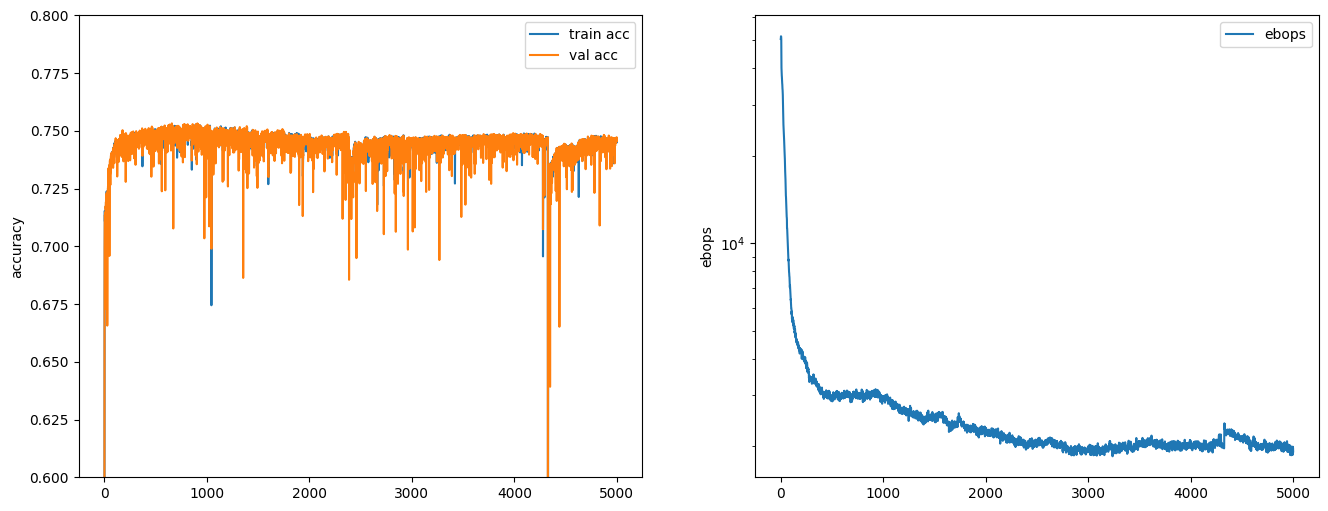

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(16,6))
axs[0].plot(history.history['accuracy'], label='train acc')
axs[0].plot(history.history['val_accuracy'], label='val acc')
axs[0].set_ylabel('accuracy')
axs[0].set_ylim(0.6,0.8)
axs[0].legend()
axs[1].plot(history.history['bops'], label='ebops')
axs[1].set_ylabel('ebops')
axs[1].set_yscale('log')
axs[1].legend()
plt.show()

In [ ]:
# MUST run trace_minmax before converting the model into a proxy model
# We determine here the exactly number of requried integer bits. The one used during training is approximated
# EBOPs produced here are more accurate

trace_minmax(model, train_fea, bsz=bsz, verbose=False)
ebops = trace_minmax(model, val_fea, bsz=bsz, verbose=True)
print(f'EBOPs: {ebops:,.0f}')

inp_quantizer: 0.0
dense_1: 825.0
dense_2: 323.0
dense_3: 238.0
output: 261.0
EBOPs: 1,647


The numbers shown above are produced in a Kaggle run.

On a local example run, the command above produces the following output:
```python
inp_quantizer: 0.0
dense_1: 950.0
dense_2: 393.0
dense_3: 280.0
output: 228.0
EBOPs: 1,851
```

After Placing & Routing (P&R) on xcvu9p-fsgd2104-2L-e FPGA:
 - latency: 5clks@5ns
 - II: 1
 - LUT: 1749
 - FF: 503
 - DSP: 4
 - WNS > 0

And EBOPs gives accurate estimation over the total resource consumption:
$1851 = EBOPs \approx LUTs + 50\cdot DSPs = 1949.$

The full vitis report is available in the next cell (hidden by default).

In [ ]:
# +---------+---------+-----------+-----------+-----+-----+---------+
# |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
# |   min   |   max   |    min    |    max    | min | max |   Type  |
# +---------+---------+-----------+-----------+-----+-----+---------+
# |        5|        5|  25.000 ns|  25.000 ns|    1|    1|      yes|
# +---------+---------+-----------+-----------+-----+-----+---------+


# WNS(ns)    WHS(ns)    WPWS(ns)
# -------    -------    --------
#   0.960      0.049       2.225

# +-------------------------+------+-------+------------+-----------+-------+
# |        Site Type        | Used | Fixed | Prohibited | Available | Util% |
# +-------------------------+------+-------+------------+-----------+-------+
# | CLB LUTs                | 1749 |     0 |          0 |   1728000 |  0.10 |
# |   LUT as Logic          | 1749 |     0 |          0 |   1728000 |  0.10 |
# |   LUT as Memory         |    0 |     0 |          0 |    791040 |  0.00 |
# | CLB Registers           |  503 |     0 |          0 |   3456000 |  0.01 |
# |   Register as Flip Flop |  503 |     0 |          0 |   3456000 |  0.01 |
# |   Register as Latch     |    0 |     0 |          0 |   3456000 |  0.00 |
# | CARRY8                  |  204 |     0 |          0 |    216000 |  0.09 |
# | F7 Muxes                |    0 |     0 |          0 |    864000 |  0.00 |
# | F8 Muxes                |    0 |     0 |          0 |    432000 |  0.00 |
# | F9 Muxes                |    0 |     0 |          0 |    216000 |  0.00 |
# +-------------------------+------+-------+------------+-----------+-------+

# +----------------+------+-------+------------+-----------+-------+
# |    Site Type   | Used | Fixed | Prohibited | Available | Util% |
# +----------------+------+-------+------------+-----------+-------+
# | DSPs           |    4 |     0 |          0 |     12288 |  0.03 |
# |   DSP48E2 only |    4 |       |            |           |       |
# +----------------+------+-------+------------+-----------+-------+

In [ ]:
# MUST perform this step to get a parsiable model by hls4ml,
# and generates all necessary metadata for hls4ml to produce bit-accurate firmwares.
proxy = to_proxy_model(model, aggressive=True)
# aggressive=True use WRAP instead of SAT for overflows. For HGQ models, this is usually fine.

# One may also pass a QKeras model to this function
# The QKeras model MUST have a quantizer immediately after the input
# new_qkeras_model = keras.Sequential([QActivation(quantized_bits(...)), original_qkeras_model]) would suffice
# MUST set aggressive=False for QKeras models as they are trained with SAT overflow mode.

In [ ]:
with shutup:
    # Just silencing the verbose output
    model_hls = convert_from_keras_model(proxy, output_dir='/tmp/tmp_model')

model_hls.write()
model_hls._compile()

Writing HLS project
Done


In [ ]:
pred_keras = model.predict(test_fea, batch_size=bsz, verbose=0)
pred_proxy = proxy.predict(test_fea, batch_size=bsz, verbose=0)
pred_hls = model_hls.predict(test_fea)

In [ ]:
n1 = np.sum(np.any(pred_proxy != pred_keras, axis=1))
n2 = np.sum(np.any(pred_hls != pred_proxy, axis=1))

# Check number of events has having **any** mismatch between the trained/proxy/hls4ml models
# This can be from either overflow or float bit rounding issue
print(f'Proxy model: {n1} / {len(test_fea)} predictions differ from base model')
print(f'HLS model: {n2} / {len(test_fea)} predictions differ from proxy model')

Proxy model: 1 / 260000 predictions differ from base model
HLS model: 0 / 260000 predictions differ from proxy model


In [ ]:
acc_base = np.mean(np.argmax(pred_keras, axis=1) == test_label)
acc_proxy = np.mean(np.argmax(pred_proxy, axis=1) == test_label)
acc_hls = np.mean(np.argmax(pred_hls, axis=1) == test_label)

# The three accuracies should be very close (typically much smaller than 0.01%)
# If not, something is going wrong
print(f'Base model accuracy: {acc_base*100}')
print(f'Proxy model accuracy: {acc_proxy*100}')
print(f'HLS model accuracy: {acc_hls*100}')

Base model accuracy: 74.65307692307692
Proxy model accuracy: 74.65307692307692
HLS model accuracy: 74.65307692307692


# Extended example: one run to cover the whole Pareto Frontier

### Profile the trade-off between model performance and resource in one run, for the small jet tagger


This is just a short demostration. For a production run, you will need to increase beta much more gradually to get good results. See https://github.com/calad0i/HGQ-demos for complete examples.

In [ ]:
model = get_model(0)
opt = keras.optimizers.Adam(learning_rate=5e-3)
loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])
bsz = 33200

In [ ]:
free_bops = FreeBOPs()
pbar = PBar('loss: {loss:.2f}/{val_loss:.2f} - acc: {accuracy:.3f}/{val_accuracy:.3f} - beta: {beta:.2e}')
reset = ResetMinMax()

max_epochs = 30000
# Approximately one more zero is needed for the best results, but this already works reasonably well

# The regularization strength, beta, is a variable that can be changed during training.
# We now ramp it up exponentially during training to scan over the pareto front.
def schedule(epoch:int):
    return 1e-4 * np.exp(3*(epoch / max_epochs - 1))

beta_scheduler = BetaScheduler(schedule)

fmt = 'ep={epoch:04d}-acc={accuracy:.3f}-val_acc={val_accuracy:.3f}-bops={bops:,.0f}.h5'

# Helper class to save all models on the Pareto Front w.r.t. to some metrics
pareto_front = PeratoFront(
    '/tmp/ckpts',                                   # path to save models
    fmt,                                            # format of the saved file name
    ['val_accuracy', 'bops'],                       # metrics to look at
    [1, -1],                                        # maximize val_accuracy, minimize ebops
    cond_fn=lambda x: x['val_accuracy'] > 0.6       # only save models with val_accuracy > 0.6
)

callbacks = [free_bops, beta_scheduler, pareto_front, pbar, reset] # reset always comes last

In [ ]:
history = model.fit(
    train_fea, train_label,
    validation_data=(val_fea, val_label),
    epochs=max_epochs,
    callbacks=callbacks,
    verbose=0,
    batch_size=bsz
)

  0%|          | 0/30000 [00:00<?, ?epoch/s]W0000 00:00:1727045028.286419     290 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
loss: 0.81/0.81 - acc: 0.719/0.725 - beta: 1.00e-04 - BOPs: 533: 100%|██████████| 30000/30000 [1:19:59<00:00,  6.25epoch/s]


In [ ]:
# update the ebops recorded are updated in filenames. (ebops in training are usually overestimated)
train_val_fea = np.concatenate([train_fea, val_fea], axis=0)
pareto_front.rename_ckpts(train_val_fea, bsz=bsz)

Renaming checkpoints: 100%|██████████| 76/76 [00:32<00:00,  2.35it/s]


#### The following are the resource-accuracy tradeoff obtained from this run. EBOPs~LUTs + 55 DSPs.

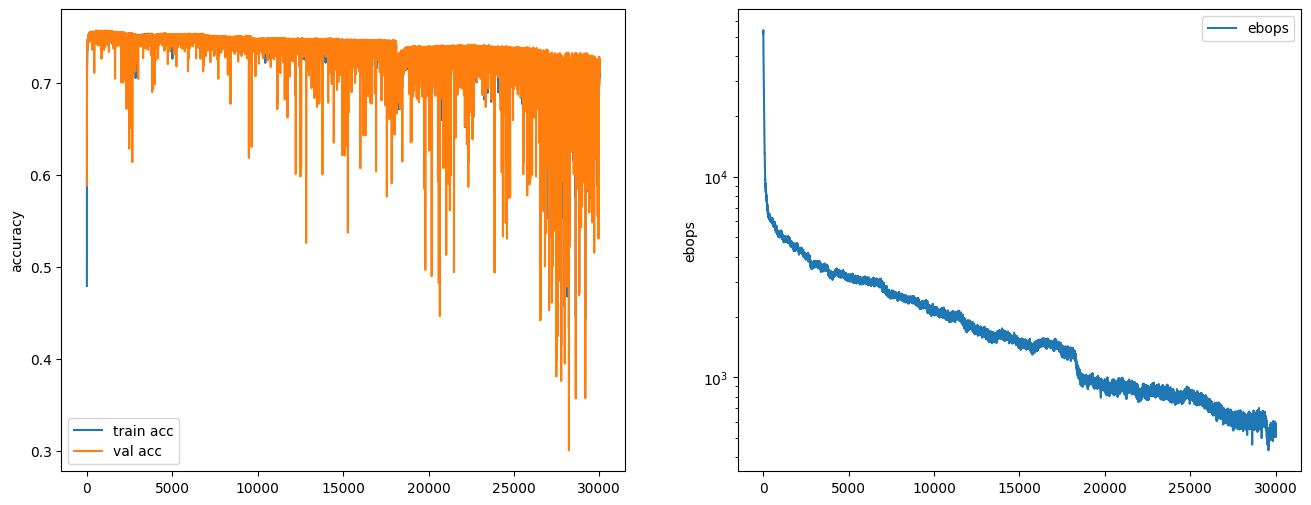

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(16,6))
axs[0].plot(model.history.history['accuracy'], label='train acc')
axs[0].plot(model.history.history['val_accuracy'], label='val acc')
axs[0].set_ylabel('accuracy')
axs[0].legend()
axs[1].plot(model.history.history['bops'], label='ebops')
axs[1].set_yscale('log')
axs[1].set_ylabel('ebops')
axs[1].legend()
plt.show()

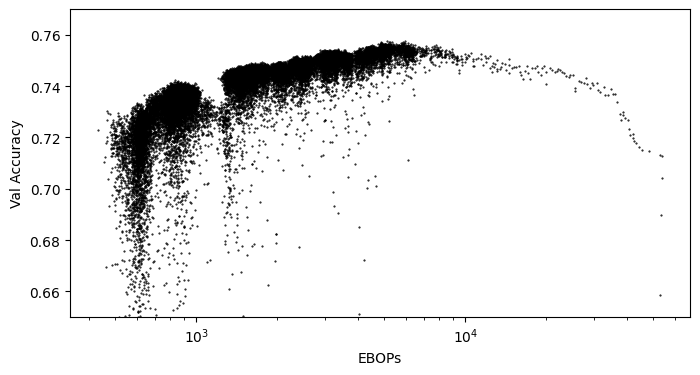

In [ ]:
fig = plt.figure(figsize=(8,4))
his_bops = history.history['bops']
his_acc = history.history['val_accuracy']
plt.plot(his_bops, his_acc, 'o', alpha=1, markersize=0.5, color='k')
plt.xlabel('EBOPs')
plt.ylabel('Val Accuracy')
plt.xscale('log')
# plt.xlim(0,10000)
plt.ylim(0.65,0.77)
plt.show()

In [ ]:
save_path = Path('/tmp/ckpts')
fnames = list(save_path.glob('*.h5'))
m = re.compile(r'ep=(\d+)-acc=(\d+\.\d+)-val_acc=(\d+\.\d+)-bops=([\d,]+)\.h5')
data = []
for fname in fnames:
    mobj = m.match(fname.name)
    assert mobj is not None
    epoch, acc, val_acc, bops = mobj.groups()
    model.load_weights(fname)
    test_acc = model.evaluate(test_fea, test_label, batch_size=bsz, verbose=0)[1]
    data.append((int(epoch), float(acc), float(val_acc), float(test_acc), int(bops.replace(',', ''))))
df = pd.DataFrame(data, columns=['epoch', 'acc', 'val_acc', 'test_acc', 'bops'])

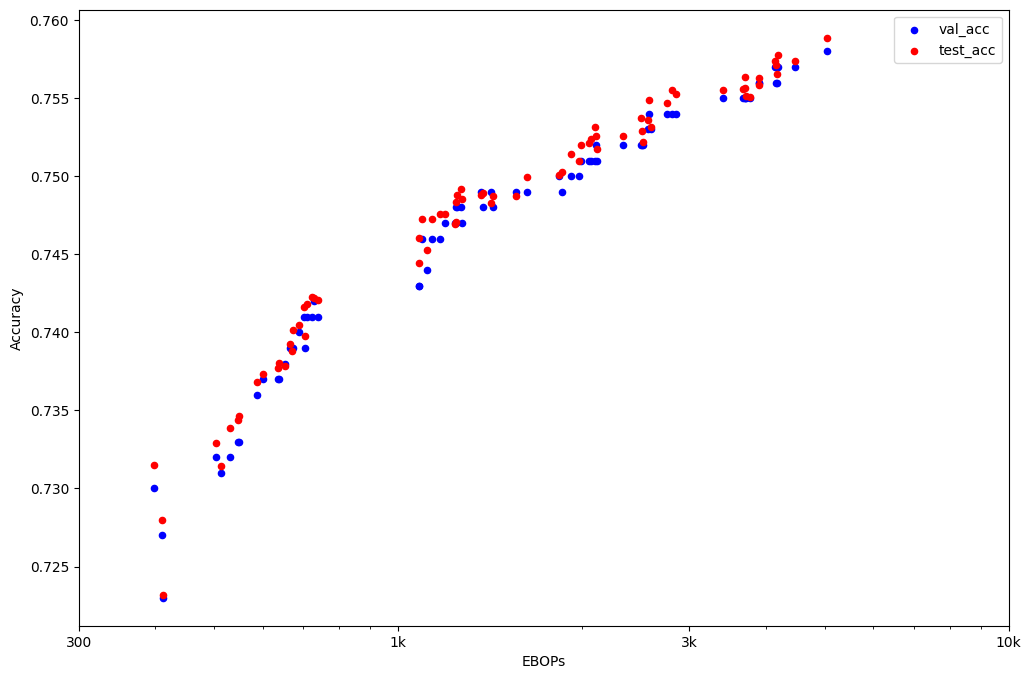

In [ ]:
# The final Pareto Front obtained.
fig, ax = plt.subplots(figsize=(8,4))
df.plot(x='bops', y='val_acc', kind='scatter', logx=True, figsize=(12,8), color='b', label='val_acc', ax=ax)
df.plot(x='bops', y='test_acc', kind='scatter', logx=True, figsize=(12,8), color='r', label='test_acc', ax=ax)
plt.xlabel('EBOPs')
plt.ylabel('Accuracy')
plt.xscale('log')
plt.xticks([300,1000,3000,10000], ['300','1k','3k','10k'])
plt.show()

#### **TIP**: Thanks to the automatic "bit-level pruning", HGQ models are not sensitive to layer sizes in general, in which, this tradeoff relation is almost invariant to the layer sizes when they are large enough.
#### Try increasing the layer sizes by 2 (`get_model(beta, scale=2)`), and run the script again. Both performance and accuracy should be similar.